In [1]:
# imports
import os
import numpy as np
import mat73
import matplotlib.pyplot as plt
import SensoriMotorPrediction.globals as gl

Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: atlases


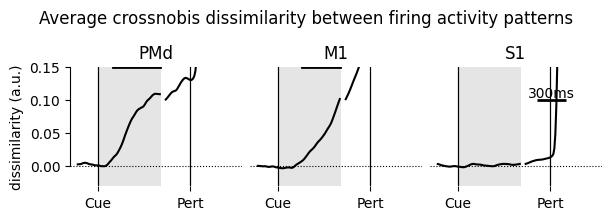

In [2]:
rois = ['PMd', 'M1', 'S1']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(6, 2), constrained_layout=True)

freq1, freq2 = 10, 20
cfg = mat73.loadmat(os.path.join('data','LFPs','cfg.mat'))['cfg']
foi = cfg['foi']
freq_mask = (foi > freq1) & (foi < freq2)
t_cue = np.linspace(0, gl.cuePost - 1, gl.cuePost)
t_pert = np.linspace(gl.pertPre, gl.pertPost - 1, gl.pertPost - gl.pertPre) + 5
t = np.concatenate((t_cue, t_pert))

vmin, vmax = 0, 1
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
model = 'Expectation'
for r, roi in enumerate(rois):
    var_tot_spk = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'sig_tot.spk.{roi}.plan.npy')).mean(axis=0)
    var_tot_spk1 = var_tot_spk[:gl.cuePost]
    var_tot_spk2 = var_tot_spk[gl.pertPre:]
    sig_spk1 = np.load(os.path.join(gl.nhpDir, gl.pcmDir, f'significant_sig_tot.spk.Cue.{roi}.plan.npy')).astype(float)
    #sig_spk1 = sig_spk1[..., 0]
    sig_spk1[sig_spk1<1] = np.nan
    sig_spk1[sig_spk1>0] = .15
    axs[r].plot(t_cue, sig_spk1, color='k', lw=2)
    axs[r].plot(t_cue, var_tot_spk1, color='k', label='firing rate')
    axs[r].plot(t_pert, var_tot_spk2, color='k')
    axs[r].axvspan(gl.cueIdx, gl.cuePost, color='grey', alpha=.2, lw=0)
    axs[r].set_ylim([None, .15])
    axs[r].set_yticks((0, .05, .1, .15))
    axs[r].spines['left'].set_bounds(0, .15)
    axs[r].axhline(0, color='k', lw=.8, ls=':')
    axs[r].set_ylabel('dissimilarity (a.u.)') if r==0 else None
    axs[r].set_title(roi)
    for i in range(2):
        axs[r].axvline(gl.cueIdx, color='k', lw='.8')
        axs[r].axvline(gl.pertIdx, color='k', lw='.8')
        axs[r].set_xticks([gl.cueIdx, gl.pertIdx])
        axs[r].set_xticklabels(['Cue', 'Pert'])
        axs[r].tick_params(left=False if r>0 else True)
        axs[r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[2].hlines(.1, xmin=100, xmax=130, color='k', lw=2)
axs[2].text(115, .1, '300ms', fontsize=10, color='k', va='bottom', ha='center')

fig.suptitle(f'Average crossnobis dissimilarity between firing activity patterns', va='center')

fig.savefig(os.path.join('figures', 'spk.plan.var_tot.pdf'))

plt.show()